In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# Download data
data = yf.download("AAPL", start="2022-01-01", end="2024-01-01")

# Moving averages
data['MA_short'] = data['Close'].rolling(window=10).mean()
data['MA_long'] = data['Close'].rolling(window=30).mean()

# Signals
data['Signal'] = 0
data.loc[data['MA_short'] > data['MA_long'], 'Signal'] = 1
data.loc[data['MA_short'] < data['MA_long'], 'Signal'] = -1

print(data.tail())

/tmp/ipython-input-311/2452140064.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", start="2022-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume  \
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL   
Date                                                                   
2023-12-22  191.609482  193.400870  190.985954  193.173224  37149600   
2023-12-26  191.065125  191.896484  190.847385  191.619364  28919300   
2023-12-27  191.164093  191.510500  189.125276  190.510890  48087700   
2023-12-28  191.589691  192.658589  191.183903  192.143931  34049900   
2023-12-29  190.550446  192.401214  189.758668  191.906355  42672100   

Price         MA_short     MA_long Signal  
Ticker                                     
Date                                       
2023-12-22  193.734395  190.117962      1  
2023-12-26  193.721527  190.337349      1  
2023-12-27  193.567130  190.612821      1  
2023-12-28  193.133635  190.815383      1  
2023-12-29  192.581371  190.964500      1  


In [2]:
def bayesian_forecast(prices, lookback=30):

    returns = prices.diff()

    up_moves = (returns > 0).rolling(lookback).sum()
    down_moves = (returns < 0).rolling(lookback).sum()

    total = up_moves + down_moves

    prob_up = up_moves / total
    prob_down = down_moves / total

    return prob_up, prob_down


data['Prob_Up'], data['Prob_Down'] = bayesian_forecast(data['Close'])

print(data[['Prob_Up','Prob_Down']].tail())


Price        Prob_Up Prob_Down
Ticker                        
Date                          
2023-12-22  0.533333  0.466667
2023-12-26  0.500000  0.500000
2023-12-27  0.533333  0.466667
2023-12-28  0.533333  0.466667
2023-12-29  0.500000  0.500000


In [3]:
def quantum_bayesian_indicator(df, lookback=30):

    returns = df['Close'].diff()

    up_moves = (returns > 0).rolling(lookback).sum()
    down_moves = (returns < 0).rolling(lookback).sum()

    total = up_moves + down_moves

    prob_up = up_moves / total

    # Trend probability
    ma_short = df['Close'].rolling(10).mean()
    ma_long = df['Close'].rolling(30).mean()

    trend = np.where(ma_short > ma_long, 1, 0)

    # Volatility amplitude
    volatility = df['Close'].rolling(lookback).std()
    vol_norm = volatility / volatility.rolling(lookback).mean()

    # Hybrid forecast probability
    forecast = 0.5*prob_up + 0.3*trend + 0.2*vol_norm

    return forecast


data['Forecast'] = quantum_bayesian_indicator(data)

print(data[['Forecast']].tail())

Price       Forecast
Ticker              
Date                
2023-12-22  0.674311
2023-12-26  0.653151
2023-12-27  0.660881
2023-12-28  0.657020
2023-12-29  0.637009


In [4]:
data['Buy'] = data['Forecast'] > 0.6
data['Sell'] = data['Forecast'] < 0.4

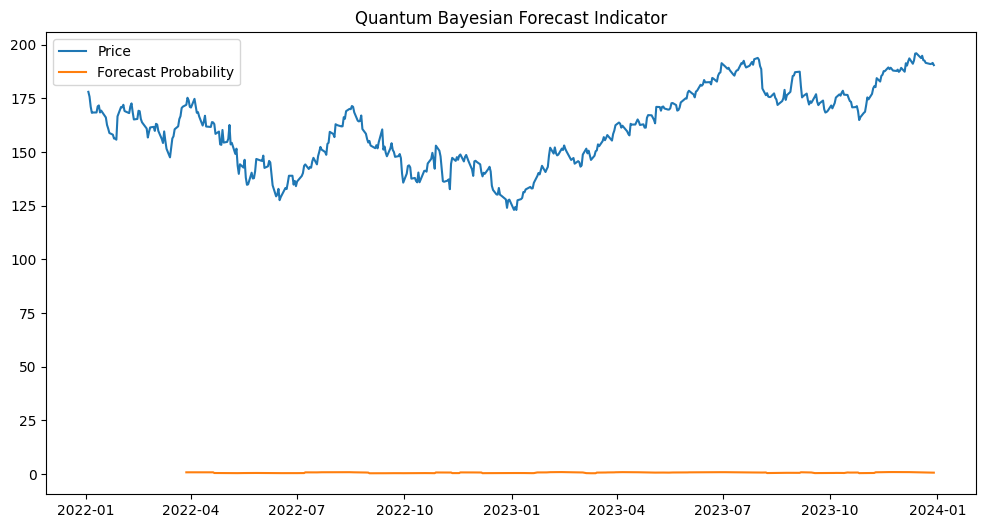

In [5]:
plt.figure(figsize=(12,6))

plt.plot(data['Close'], label='Price')
plt.plot(data['Forecast'], label='Forecast Probability')

plt.legend()
plt.title("Quantum Bayesian Forecast Indicator")

plt.show()

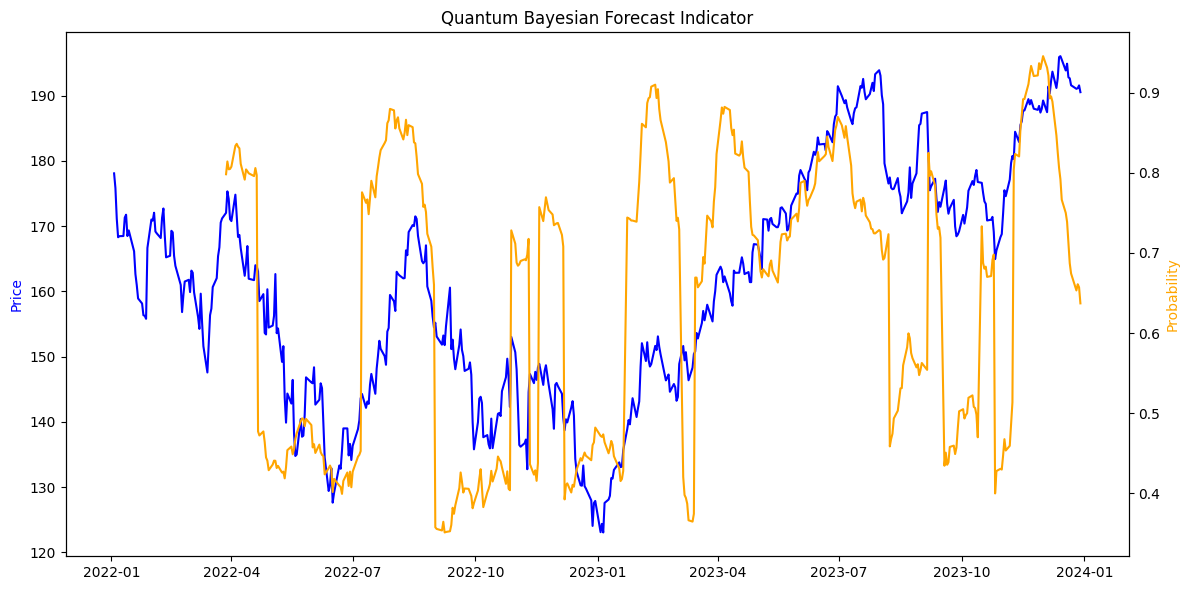

In [6]:
fig, ax1 = plt.subplots(figsize=(12,6))

# Price axis
ax1.plot(data.index, data['Close'], color='blue', label='Price')
ax1.set_ylabel("Price", color='blue')

# Second axis for probability
ax2 = ax1.twinx()
ax2.plot(data.index, data['Forecast'], color='orange', label='Forecast Probability')
ax2.set_ylabel("Probability", color='orange')

plt.title("Quantum Bayesian Forecast Indicator")

fig.tight_layout()
plt.show()